# Emotion Classifier Reliability Under Temporal and Cross-Lingual Domain Shift
### A Computational Study on English (The Valley of Fear, 1915) and Hindi (Gaban, 1936) Literary Dialogue

This notebook reproduces every quantitative result in the accompanying paper.
The primary classifier is a multilingual model (tabularisai), validated on both
English and Hindi to isolate a within-model, language-attributable reliability
drop; an English-only model (j-hartmann) is included as an additional strong
baseline. A top-to-bottom Restart & Run All regenerates all figures and
statistics from three human-annotation inputs: manual_annotations_50turns.csv
(English, baseline-selected), english_tab_validation_annotated.csv (English,
multilingual-selected), and gaban_validation_annotated.csv (Hindi). All
randomized procedures are seeded.


## 1. Setup & Imports

In [1]:
import os
import re
import pickle
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report

# ── Shared constants (defined once, reused everywhere) ──────────────────────
EMOTION_LABELS     = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']
LABEL2IDX          = {label: i for i, label in enumerate(EMOTION_LABELS)}
NEUTRAL_IDX        = EMOTION_LABELS.index('neutral')          # 4
NON_NEUTRAL_LABELS = [l for l in EMOTION_LABELS if l != 'neutral']
EMOTION_MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"

# ── Cross-lingual primary model (Hindi) ──────────────────────────────────────
HINDI_MODEL_NAME = "tabularisai/multilingual-emotion-classification"
FULL_LABELS   = ['anger', 'contempt', 'disgust', 'fear', 'frustration',
                 'gratitude', 'joy', 'love', 'neutral', 'sadness', 'surprise']  # tabularisai native 11
PARITY_LABELS = EMOTION_LABELS                                  # 7 labels shared with j-hartmann
PARITY_IDX    = [FULL_LABELS.index(l) for l in PARITY_LABELS]   # restrict tabularisai to the shared 7

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)


## 2. English Corpus: The Valley of Fear (Doyle, 1915)

In [2]:
class NovelPreprocessor:
    """Preprocess a novel into turn-based dialogue format with improved extraction."""

    def __init__(self, unknown_default='UNK'):
        self.unknown_default = unknown_default
        self.speaker_map = self._build_speaker_map()
        self.unknown_speakers = set()
        # Expanded list of speech verbs
        self.speech_verbs = [
            'said', 'replied', 'asked', 'cried', 'murmured', 'whispered', 'hissed',
            'shouted', 'observed', 'remarked', 'answered', 'called', 'muttered',
            'continued', 'added', 'began', 'suggested', 'agreed', 'exclaimed',
            'gasped', 'snapped', 'drawled', 'yelled', 'screamed', 'bellowed',
            'roared', 'snarled', 'growled', 'snorted', 'scoffed', 'retorted',
            'queried', 'demanded', 'ordered', 'commanded', 'implored', 'pleaded',
            'sobbed', 'wept', 'laughed', 'chuckled', 'grinned', 'smiled'
        ]

    def _build_speaker_map(self):
        """Return a dict mapping character name patterns to group 'A' or 'B'."""
        # Extended mapping based on novel characters
        mapping = {
            # Protagonists → A
            'Holmes': 'A', 'Sherlock Holmes': 'A', 'Mr. Holmes': 'A',
            'Watson': 'A', 'Dr. Watson': 'A', 'Doctor Watson': 'A',
            'Douglas': 'A', 'John Douglas': 'A', 'Mr. Douglas': 'A',
            'Birdy Edwards': 'A', 'Edwards': 'A',
            'Jack McMurdo': 'A', 'McMurdo': 'A',
            'MacDonald': 'A', 'Alec MacDonald': 'A', 'Inspector MacDonald': 'A',
            'Ettie': 'A', 'Ettie Shafter': 'A', 'Mrs. Shafter': 'A',
            'Barker': 'A', 'Cecil Barker': 'A', 'Mr. Barker': 'A',
            'White Mason': 'A',
            # Antagonists → B
            'Moriarty': 'B', 'Professor Moriarty': 'B',
            'McGinty': 'B', 'John McGinty': 'B', 'Black Jack': 'B',
            'Porlock': 'B', 'Fred Porlock': 'B',
            'Morris': 'B', 'Mike Scanlan': 'B', 'Scanlan': 'B',
            'Cormac': 'B', 'Marks': 'B', 'Lawler': 'B', 'Andrew Lawler': 'B',
            'Carter': 'B', 'Willaby': 'B', 'Jacob Shafter': 'B',
            'Ames': 'B',
            'Ted Baldwin': 'B', 'Baldwin': 'B'

        }

        return mapping

    def _map_speaker(self, speaker_name):
        """Convert speaker name to group 'A', 'B', or 'UNK'."""
        speaker_clean = speaker_name.strip()
        for pattern, group in self.speaker_map.items():
            if re.search(r'\b' + re.escape(pattern) + r'\b', speaker_clean, re.IGNORECASE):
                return group
        self.unknown_speakers.add(speaker_clean)
        return self.unknown_default

    def load_novel(self, filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            return f.read()

    def segment_into_chapters(self, text):
        """Split after the Gutenberg header, using 'CHAPTER' markers."""
        # Find first occurrence of "CHAPTER" (case‑insensitive) – skip preceding boilerplate
        match = re.search(r'(?i)(CHAPTER\s+[IVXLC\d]+)', text)
        if not match:
            # Fallback: treat whole text as one chapter
            return [{'chapter_id': 0, 'text': text}]
        start_pos = match.start()
        # From there, split on each chapter heading
        chapter_pattern = r'(?i)(CHAPTER\s+[IVXLC\d]+)'
        splits = re.split(chapter_pattern, text[start_pos:])
        # The first element is the intro before first chapter heading (should be empty or very short)
        chapters = []
        for i in range(1, len(splits), 2):
            chap_title = splits[i]
            chap_text = splits[i+1] if i+1 < len(splits) else ''
            # Combine title and text for context, but we can discard title for analysis
            full_text = chap_text.strip()
            if len(full_text) > 100:
                chapters.append({'chapter_id': len(chapters), 'text': full_text})
        return chapters

    def extract_dialogue(self, text):
        """
        Extract dialogues with attribution before or after the quote,
        PLUS colon-based attribution (e.g., McMurdo: "...").
        """
        # Normalize quotes
        text = re.sub(r'[“”]', '"', text)

        verbs = '|'.join(self.speech_verbs)

        # Pattern 1: After-quote attribution
        pattern_after = r'"([^"]+)"\s*,?\s*(?:' + verbs + r')\s+([A-Z][a-zA-Z]*(?:\s+[A-Z][a-zA-Z]*)?)'

        # Pattern 2: Before-quote attribution
        pattern_before = r'([A-Z][a-zA-Z]*(?:\s+[A-Z][a-zA-Z]*)?)\s+(?:' + verbs + r'),\s*"([^"]+)"'

        # Pattern 3: Colon-based attribution
        pattern_colon = r'([A-Z][a-zA-Z]*(?:\s+[A-Z][a-zA-Z]*)?):\s*"([^"]+)"'

        dialogues = []

        # After-quote matches
        for match in re.finditer(pattern_after, text, re.DOTALL):
            utterance = match.group(1).strip().replace('\n', ' ')
            speaker = match.group(2).strip()
            if speaker.lower() in {'he', 'she', 'it', 'they', 'we', 'you', 'i'}:
                continue
            dialogues.append({
                'speaker_raw': speaker,
                'speaker_group': self._map_speaker(speaker),
                'text': utterance,
                'position': match.start()
            })

        # Before-quote matches
        for match in re.finditer(pattern_before, text, re.DOTALL):
            speaker = match.group(1).strip()
            utterance = match.group(2).strip().replace('\n', ' ')
            if speaker.lower() in {'he', 'she', 'it', 'they', 'we', 'you', 'i'}:
                continue
            dialogues.append({
                'speaker_raw': speaker,
                'speaker_group': self._map_speaker(speaker),
                'text': utterance,
                'position': match.start()
            })

        # Colon-based matches
        for match in re.finditer(pattern_colon, text, re.DOTALL):
            speaker = match.group(1).strip()
            utterance = match.group(2).strip().replace('\n', ' ')
            if speaker.lower() in {'he', 'she', 'it', 'they', 'we', 'you', 'i'}:
                continue
            dialogues.append({
                'speaker_raw': speaker,
                'speaker_group': self._map_speaker(speaker),
                'text': utterance,
                'position': match.start()
            })

        # Sort by position
        dialogues.sort(key=lambda x: x['position'])

        return dialogues

    def create_turn_dataset(self, chapters):
        all_turns = []
        for chapter in tqdm(chapters, desc="Processing chapters"):
            dialogues = self.extract_dialogue(chapter['text'])
            if not dialogues:
                continue
            for i, dia in enumerate(dialogues):
                # Skip if speaker_group is 'UNK' – we may later decide to include or exclude
                if dia['speaker_group'] == 'UNK':
                    continue   # exclude unknown speakers from analysis
                # Build context of up to 4 previous utterances
                context_start = max(0, i - 4)
                context_turns = dialogues[context_start:i]
                while len(context_turns) < 4:
                    context_turns.insert(0, {'speaker_group': 'PAD', 'text': '', 'speaker_raw': ''})
                # Find previous utterance by same speaker group (for shift calculation)
                prev_same = None
                for j in range(i-1, -1, -1):
                    if dialogues[j]['speaker_group'] == dia['speaker_group']:
                        prev_same = dialogues[j]
                        break
                turn = {
                    'chapter_id': chapter['chapter_id'],
                    'turn_idx': i,
                    'speaker': dia['speaker_group'],
                    'speaker_raw': dia['speaker_raw'],
                    'text': dia['text'],
                    'context_turns': context_turns,
                    'has_previous': prev_same is not None,
                    'previous_text': prev_same['text'] if prev_same else None,
                    'previous_speaker': prev_same['speaker_group'] if prev_same else None,
                }
                all_turns.append(turn)
        return pd.DataFrame(all_turns)

    def save_processed_data(self, turns_df, filepath="novel_processed.pkl"):
        data = {'turns': turns_df}
        with open(filepath, 'wb') as f:
            pickle.dump(data, f)
        turns_df.to_csv(filepath.replace('.pkl', '.csv'), index=False)
        print(f"Saved processed data to {filepath}")
        return filepath

In [3]:
NOVEL_PATH = "valley_of_fear.txt"
NOVEL_URL  = "https://www.gutenberg.org/cache/epub/3776/pg3776.txt"

if not os.path.exists(NOVEL_PATH):
    print("Downloading novel text ...")
    urllib.request.urlretrieve(NOVEL_URL, NOVEL_PATH)

pre = NovelPreprocessor(unknown_default='UNK')
text = pre.load_novel(NOVEL_PATH)
chapters = pre.segment_into_chapters(text)
turns_df = pre.create_turn_dataset(chapters)

print(f"Chapters detected: {len(chapters)}")
print(f"Total turns (excluding UNK): {len(turns_df)}")
print(turns_df['speaker'].value_counts())

pre.save_processed_data(turns_df, filepath="valley_of_fear_processed.pkl")

Processing chapters:   0%|          | 0/16 [00:00<?, ?it/s]

Chapters detected: 16
Total turns (excluding UNK): 172
speaker
A    116
B     56
Name: count, dtype: int64
Saved processed data to valley_of_fear_processed.pkl


'valley_of_fear_processed.pkl'

## 3. Hindi Corpus: Gaban (Premchand, 1936)

In [5]:
# ── Gaban: reassemble gaban_raw.txt with site chrome stripped ───────────────
import os, re, urllib.parse

DEVANAGARI = re.compile(r"[ऀ-ॿ]")
def dev_count(s):
    return len(DEVANAGARI.findall(s))

# hindisamay chapter URLs: n = 1..5 indexes the /226/{n}/ path segment.
BASE = "https://www.hindisamay.com/content/226/{n}/प्रेमचंद--धनपत-राय-उपन्यास-गबन-अध्याय-1.cspx"
HEADERS = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
                         "(KHTML, like Gecko) Chrome/124.0 Safari/537.36"}

def fetch_chapter(n):
    """Download one chapter page and return its visible text (HTML stripped)."""
    import requests
    from bs4 import BeautifulSoup
    sp = urllib.parse.urlsplit(BASE.format(n=n))
    url = urllib.parse.urlunsplit(
        (sp.scheme, sp.netloc, urllib.parse.quote(sp.path), sp.query, sp.fragment))
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    r.encoding = r.apparent_encoding or "utf-8"
    soup = BeautifulSoup(r.text, "html.parser")
    for tag in soup(["script", "style", "nav", "header", "footer", "noscript"]):
        tag.decompose()
    return soup.get_text("\n")

pages, download_ok = [], True
for n in range(1, 6):
    try:
        txt = fetch_chapter(n)
        dc = dev_count(txt)
        print(f"chapter {n}: fetched ok, {dc:,} Devanagari chars")
        if dc < 2000:
            print(f"   -> chapter {n} looks like nav junk (< 2000 Devanagari chars)")
            download_ok = False
        pages.append(txt)
    except Exception as e:
        print(f"chapter {n}: request FAILED -> {e!r}")
        download_ok = False

if download_ok and pages and dev_count("\n".join(pages)) >= 2000:
    source_text, source = "\n".join(pages), "hindisamay download (5 chapters)"
else:
    manual = [f"gaban_{n}.txt" for n in range(1, 6)]
    have = [f for f in manual if os.path.exists(f)]
    if have:
        parts = []
        for f in manual:
            if os.path.exists(f):
                with open(f, encoding="utf-8") as fh:
                    parts.append(fh.read())
        source_text, source = "\n".join(parts), f"manual files ({len(have)}/5 present)"
    elif os.path.exists("gaban_raw.txt"):
        with open("gaban_raw.txt", encoding="utf-8") as fh:
            source_text = fh.read()
        source = "existing gaban_raw.txt (re-cleaned)"
    else:
        raise FileNotFoundError(
            "No source available: download failed and no gaban_1..5.txt / "
            "gaban_raw.txt present. Save the 5 chapter pages and re-run.")

# Strip site chrome: drop any line with Latin letters, and drop exact
#    nav/footer tokens from the blocklist.
LATIN = re.compile(r"[A-Za-z]")
BLOCKLIST = {"शब्द चर्चा", "अन्यत्र", "जिज्ञासा", "जीवनी", "कोश", "समग्र-संचयन",
             "अज्ञेय रचना संचयन", "कबीर ग्रंथावली", "मोहन राकेश संचयन",
             "हमारे रचनाकार", "हिंदी लेखक", "अभिलेखागार", "संपर्क", "मुखपृष्ठ",
             "उपन्यास", "कहानी", "कविता", "व्यंग्य", "नाटक", "निबंध", "आलोचना",
             "विमर्श"}

cleaned_lines = []
for line in source_text.split("\n"):
    if LATIN.search(line):           # any Latin letter -> site chrome, drop line
        continue
    if line.strip() in BLOCKLIST:    # exact nav/footer token, drop line
        continue
    cleaned_lines.append(line)
cleaned = "\n".join(cleaned_lines)

with open("gaban_raw.txt", "w", encoding="utf-8") as f:
    f.write(cleaned)

print(f"\nSource: {source}")
print(f"Total Devanagari chars after chrome strip: {dev_count(cleaned):,}")
print("Saved -> gaban_raw.txt  (chrome stripped)")

chapter 1: fetched ok, 49,654 Devanagari chars
chapter 2: fetched ok, 98,419 Devanagari chars
chapter 3: fetched ok, 92,558 Devanagari chars
chapter 4: fetched ok, 73,648 Devanagari chars
chapter 5: fetched ok, 86,010 Devanagari chars

Source: hindisamay download (5 chapters)
Total Devanagari chars after chrome strip: 398,811
Saved -> gaban_raw.txt  (chrome stripped)


In [6]:
# ── Gaban: SENTENCE-BOUNDED extraction with fixed dialogue rule ─────────────
# Precision-first; speaker is best-effort. Catches unquoted speech via in-sentence
# and end-of-sentence attribution and keeps narration out.
import os, re, urllib.parse
import pandas as pd

DEVA = re.compile(r"[ऀ-ॿ]")
def dev_count(s):
    return len(DEVA.findall(s))

# Reuse the cleaned corpus.
with open("gaban_raw.txt", encoding="utf-8") as f:
    cleaned = f.read()

# Speech verbs (correct Devanagari पूछा/टोका; includes बोली/बोला/बोले/पूछा).
# Longest-first so multi-word verbs win over their single-token substrings.
SPEECH_VERBS = ["ने कहा कि", "ने जवाब दिया", "जवाब दिया", "ने कहा", "ने पूछा",
                "ने टोका", "बोल उठा", "बोल उठी", "चिल्लाया", "चिल्लाई", "कहकर",
                "कहा", "बोला", "बोली", "बोले", "पूछा", "टोका"]
VERB_ALT = "|".join(re.escape(v) for v in sorted(SPEECH_VERBS, key=len, reverse=True))
SEP = r"(?:--|[-–—:,])"                                       # -- – — - : ,
VERBSEP = re.compile(r"(?:" + VERB_ALT + r")\s*" + SEP)       # verb + separator
TAIL = re.compile(r"((?:[ऀ-ॿ]+\s+){0,2}[ऀ-ॿ]+)\s*$")         # 1–3 trailing tokens
POSTPOS = {"ने", "को", "से", "का", "की", "के"}
LATIN = re.compile(r"[A-Za-z]")
QSTRIP = " \t\r\n“”‘’\"'"
QUOTE_PAIRS = [("“", "”"), ("‘", "’"), ('"', '"'), ("'", "'")]

def clean_speaker(name):
    toks = name.split()
    while toks and toks[-1] in POSTPOS:    # drop trailing ने/को/से/का/की/के
        toks.pop()
    return " ".join(toks)

def speaker_before(pre):
    m = TAIL.search(pre)
    return clean_speaker(m.group(1)) if m else ""

def quoted_inside(s):
    """First quote pair in s whose inside has >= 3 Devanagari chars."""
    for o, c in QUOTE_PAIRS:
        m = re.search(re.escape(o) + r"(.*?)" + re.escape(c), s, re.DOTALL)
        if m and dev_count(m.group(1)) >= 3:
            return m.group(1)
    return None

# SENTENCE SPLIT on । ? ! and newlines, in order; strip; keep non-empty pieces
#    with their document positions. Bounded sentences S[0..n-1].
SPLIT = re.compile(r"[।?!\n]")
pieces, last = [], 0
for m in SPLIT.finditer(cleaned):
    pieces.append((cleaned[last:m.start()], last))
    last = m.end()
pieces.append((cleaned[last:], last))
sentences = [(p.strip(), start) for (p, start) in pieces if p.strip()]

# Classify each sentence by the FIRST matching rule. A sentence consumed as the
#    S_{i+1} of a rule-(b) match is not independently re-emitted.
cands, consumed, n = [], set(), len(sentences)
for i in range(n):
    if i in consumed:
        continue
    s, start = sentences[i]
    matches = list(VERBSEP.finditer(s))
    if matches:
        m0 = matches[0]
        rest = s[m0.end():]
        if dev_count(rest) >= 3:                       # (a) in-sentence attribution
            cands.append({"pos": start, "speaker_raw": speaker_before(s[:m0.start()]),
                          "text": rest, "rule": "a"})
        elif i + 1 < n:                                # (b) end attribution -> next
            cands.append({"pos": start, "speaker_raw": speaker_before(s[:m0.start()]),
                          "text": sentences[i + 1][0], "rule": "b"})
            consumed.add(i + 1)
        continue
    inside = quoted_inside(s)
    if inside is not None:                             # (c) quoted
        cands.append({"pos": start, "speaker_raw": "", "text": inside, "rule": "c"})
    # (d) else: narration -> drop

# HARD INVARIANT FILTER — strip quotes/space, then DROP (never fix) units with
#    Devanagari length out of [3, 150], a residual danda, or any Latin letter.
kept = []
for c in cands:
    t = c["text"].strip(QSTRIP)
    nd = dev_count(t)
    if nd < 3 or nd > 150:
        continue
    if "।" in t or LATIN.search(t):
        continue
    c["text"] = t
    kept.append(c)

# Remove exact duplicates, then substrings (keep the longer). turn_id in doc order.
seen, dd = set(), []
for c in kept:
    if c["text"] in seen:
        continue
    seen.add(c["text"])
    dd.append(c)
texts = [c["text"] for c in dd]
final = [c for c in dd
         if not any(c["text"] != o and c["text"] in o for o in texts)]
final.sort(key=lambda c: c["pos"])
for i, c in enumerate(final):
    c["turn_id"] = i

gaban_turns = pd.DataFrame(final, columns=["turn_id", "speaker_raw", "text"])
gaban_turns.to_csv("gaban_turns.csv", index=False)

# Rule counts kept in memory for the PROOF cell (CSV stays 3 columns).
GABAN_RULE_COUNTS = {r: sum(c["rule"] == r for c in final) for r in ("a", "b", "c")}
print(f"Total turns: {len(gaban_turns)}")
print(f"  rule (a) in-sentence: {GABAN_RULE_COUNTS['a']}   "
      f"(b) end->next: {GABAN_RULE_COUNTS['b']}   "
      f"(c) quoted: {GABAN_RULE_COUNTS['c']}")
print("Saved -> gaban_turns.csv  (sentence-bounded, fixed dialogue rule)")

Total turns: 1044
  rule (a) in-sentence: 1018   (b) end->next: 7   (c) quoted: 19
Saved -> gaban_turns.csv  (sentence-bounded, fixed dialogue rule)


In [7]:
# ── Gaban: PROOF + sample — dialogue gate before any prediction ─────────────
import re
import numpy as np
import pandas as pd

gt = pd.read_csv("gaban_turns.csv")
gt["speaker_raw"] = gt["speaker_raw"].fillna("")
DEVA = re.compile(r"[ऀ-ॿ]")
lens = gt["text"].map(lambda t: len(DEVA.findall(str(t))))

n = len(gt)
print(f"Total turns: {n}")
try:
    rc = GABAN_RULE_COUNTS
    print(f"  rule (a) in-sentence: {rc['a']}   (b) end->next: {rc['b']}   "
          f"(c) quoted: {rc['c']}")
except NameError:
    print("  rule (a)/(b)/(c) counts: (run the extraction cell this session)")
if n:
    print(f"Devanagari length — max: {int(lens.max())}, "
          f"median: {int(np.median(lens))}, "
          f"95th pct: {int(np.percentile(lens, 95))}")
    print(f"Units > 150 chars: {int((lens > 150).sum())}   (must be ~0)")
n_danda = int(gt["text"].map(lambda t: "।" in str(t)).sum())
print(f"Units containing a danda ।: {n_danda}   (must be 0)")

# 25 random sampled turns (seed=42) as turn_id | text.
k = min(25, n)
sample = gt.sample(n=k, random_state=42).sort_values("turn_id")
print(f"\nShowing {k} randomly sampled turns (seed=42):\n")
print(f"{'turn_id':>7} | text")
print("-" * 92)
for _, r in sample.iterrows():
    print(f"{int(r['turn_id']):>7} | {r['text']}")

Total turns: 1044
  rule (a) in-sentence: 1018   (b) end->next: 7   (c) quoted: 19
Devanagari length — max: 134, median: 26, 95th pct: 67
Units > 150 chars: 0   (must be ~0)
Units containing a danda ।: 0   (must be 0)

Showing 25 randomly sampled turns (seed=42):

turn_id | text
--------------------------------------------------------------------------------------------
     31 | क्या करोगी पूछकर बहन, जो होना था सो हो गया
    158 | आइए बाबूजी, ऊपर आइए
    168 | तुम्हें आशीर्वाद देती हूं, ईश्वर तुम्हारी सारी मनोकामनाएं पूरी करे
    231 | आइए, यह मेरे पिता हैं, और यह मेरे दोस्त रमेश बाबू हैं, लेकिन उन दोनों सज्जनों ने न हाथ बढ़ाया और न जगह से हिले
    244 | बाबू साहब, चीज़ें कितनी बनीं और कितनी बिकीं, आपने तो दुकान पर आना ही छोड़ दिया
    261 | सच तो है, इन्हें क्यों नहीं सर्राफ की दुकान पर ले जाते,चीज़ आंखों से देखकर इन्हें संतोष हो जायगा
    280 | ये इतने लङके किधर से आ गए
    312 | तुम अभी यहीं खड़े हो
    346 | तो फिर बतलातीं क्यों नहीं
    361 | आपका टिकट
    536 | तब चरस के पैसे मै

## 4. Emotion Prediction

### 4.1 Primary model check (tabularisai smoke test)

In [8]:
# ── Cross-lingual (Hindi) arm — model smoke test only ───────────────────────

import torch
import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load the multilingual (XLM-RoBERTa) emotion model: 11 classes, multi-label head.
hi_tokenizer = AutoTokenizer.from_pretrained(HINDI_MODEL_NAME)
hi_model = AutoModelForSequenceClassification.from_pretrained(HINDI_MODEL_NAME).eval()


# Probe sentences; the last two are neutral lines that contain an emotion keyword
# (the keyword-leakage failure mode this study tracks).
hindi_probes = [
    ("clear anger",   "तुमने मेरा सब कुछ बरबाद कर दिया, मैं तुम्हें छोड़ूँगा नहीं!"),
    ("clear sadness", "मेरे पास अब कुछ नहीं बचा, सब चला गया।"),
    ("clear joy",     "आज मेरी बेटी की शादी है, मैं बहुत खुश हूँ!"),
    ("clear fear",    "वहाँ अँधेरे में कोई खड़ा है, मुझे बहुत डर लग रहा है।"),
    ("plain neutral", "उसने खेत की ओर देखा और चुपचाप चलता रहा।"),
    ("neutral+keyword: no need to fear", "कोई बात नहीं, डरने की कोई ज़रूरत नहीं।"),
    ("neutral+keyword: 'for God's sake, end it here'", "भगवान के लिए, अब यह बात यहीं खत्म करो।"),
]


def _full_top3(logits):
    """Model's own multi-label view: sigmoid top-3 over all 11 FULL_LABELS."""
    sig = torch.sigmoid(logits)
    vals, idx = torch.topk(sig, 3)
    return ", ".join(f"{FULL_LABELS[i]} {v:.2f}" for v, i in zip(vals.tolist(), idx.tolist()))


print(f"Model: {HINDI_MODEL_NAME}")
print(f"Parity taxonomy (= j-hartmann's 7): {PARITY_LABELS}\n")

header = f"{'case':<46} {'parity_pred':<11} {'p(pred)':>8}   full_top3 (sigmoid)"
print(header)
print("-" * len(header))
with torch.no_grad():
    for case, text in hindi_probes:
        inputs = hi_tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
        logits = hi_model(**inputs).logits.squeeze(0)
        parity_probs = torch.softmax(logits[PARITY_IDX], dim=-1)  # restrict to the shared 7
        p, j = torch.max(parity_probs, dim=-1)
        parity_pred = PARITY_LABELS[int(j)]
        print(f"{case:<46} {parity_pred:<11} {float(p):>8.2f}   {_full_top3(logits)}")


config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model: tabularisai/multilingual-emotion-classification
Parity taxonomy (= j-hartmann's 7): ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

case                                           parity_pred  p(pred)   full_top3 (sigmoid)
-----------------------------------------------------------------------------------------
clear anger                                    anger           0.99   anger 0.87, love 0.74, sadness 0.06
clear sadness                                  sadness         1.00   sadness 0.99, fear 0.13, neutral 0.04
clear joy                                      joy             1.00   joy 0.99, love 0.04, gratitude 0.04
clear fear                                     fear            1.00   fear 0.99, sadness 0.02, neutral 0.01
plain neutral                                  neutral         1.00   neutral 0.98, sadness 0.01, love 0.01
neutral+keyword: no need to fear               neutral         1.00   neutral 0.98, fear 0.01, sadness 0.01
neutral+keywor

### 4.2 tabularisai on English

In [9]:
# ── tabularisai prediction: primary model over the English turns ─────────────
import torch
_idx = [FULL_LABELS.index(l) for l in PARITY_LABELS]
_texts = turns_df["text"].astype(str).tolist()
_pred, _prob = [], []
hi_model.eval()
with torch.no_grad():
    for i in range(0, len(_texts), 16):
        enc = hi_tokenizer(_texts[i:i+16], return_tensors="pt", padding=True,
                           truncation=True, max_length=128).to(hi_model.device)
        pr = hi_model(**enc).logits[:, _idx].softmax(-1)
        mx, j = pr.max(-1)
        _pred += [PARITY_LABELS[k] for k in j.tolist()]; _prob += mx.tolist()
english_tab = turns_df.copy()
english_tab["parity_pred"] = _pred; english_tab["pred_prob"] = _prob
english_tab.to_csv("english_tab_pred.csv", index=False)
print("tabularisai/English neutral rate:",
      round((english_tab.parity_pred=='neutral').mean(),3))
print("Non-neutral distribution (counts, descending):")
nonneut = english_tab.loc[english_tab["parity_pred"] != "neutral", "parity_pred"].value_counts()
if len(nonneut):
    for lbl, cnt in nonneut.items():
        print(f"  {lbl:<10} {int(cnt)}")
else:
    print("  (none — every turn predicted neutral)")

tabularisai/English neutral rate: 0.506
Non-neutral distribution (counts, descending):
  anger      20
  fear       19
  joy        18
  surprise   18
  sadness    9
  disgust    1


### 4.3 tabularisai on Hindi (Gaban)

In [10]:
# ── Hindi prediction: tabularisai over the clean Gaban turns ─────────────────
import os, re
import pandas as pd
import torch

hi_model = hi_model.eval()

# Load the clean turns; strip stray leading/trailing quote chars (“ ” ‘ ’ " ')
#    and whitespace, then drop any row left with < 3 Devanagari chars. turn_id is
#    preserved (never reindexed).
QUOTE_WS = " \t\r\n“”‘’\"'"
DEVANAGARI = re.compile(r"[ऀ-ॿ]")

df = pd.read_csv("gaban_turns.csv")
df["speaker_raw"] = df["speaker_raw"].fillna("")
df["text"] = df["text"].astype(str).map(lambda s: s.strip(QUOTE_WS))
before = len(df)
df = df[df["text"].map(lambda t: len(DEVANAGARI.findall(t)) >= 3)].reset_index(drop=True)
print(f"Loaded {before} turns; {len(df)} kept after quote/whitespace cleanup ")

# Batched parity prediction: argmax of softmax over the 7 parity logits.
BATCH = 16
texts = df["text"].tolist()
parity_preds, pred_probs = [], []
with torch.no_grad():
    for i in range(0, len(texts), BATCH):
        batch = texts[i:i + BATCH]
        inputs = hi_tokenizer(batch, return_tensors="pt", truncation=True,
                              max_length=128, padding=True)
        logits = hi_model(**inputs).logits
        parity_probs = torch.softmax(logits[:, PARITY_IDX], dim=-1)
        p, j = torch.max(parity_probs, dim=-1)
        parity_preds.extend(PARITY_LABELS[int(x)] for x in j.tolist())
        pred_probs.extend(float(x) for x in p.tolist())

df["parity_pred"] = parity_preds
df["pred_prob"] = pred_probs
df[["turn_id", "speaker_raw", "text", "parity_pred", "pred_prob"]].to_csv(
    "gaban_pred.csv", index=False)

# Report: total predicted, overall neutral rate, non-neutral distribution.
n = len(df)
hi_neutral_rate = float((df["parity_pred"] == "neutral").mean()) if n else 0.0
print(f"\nTotal turns predicted: {n}")
print(f"Overall neutral rate (Hindi): {hi_neutral_rate:.1%}")
print("Non-neutral distribution (counts, descending):")
nonneut = df.loc[df["parity_pred"] != "neutral", "parity_pred"].value_counts()
if len(nonneut):
    for lbl, cnt in nonneut.items():
        print(f"  {lbl:<10} {int(cnt)}")
else:
    print("  (none — every turn predicted neutral)")

print("Saved -> gaban_pred.csv")

Loaded 1044 turns; 1044 kept after quote/whitespace cleanup 

Total turns predicted: 1044
Overall neutral rate (Hindi): 49.0%
Non-neutral distribution (counts, descending):
  anger      166
  sadness    139
  fear       87
  joy        53
  surprise   47
  disgust    40
Saved -> gaban_pred.csv


### 4.4 j-hartmann on English (additional baseline)

In [11]:
emotion_tokenizer = AutoTokenizer.from_pretrained(EMOTION_MODEL_NAME)
emotion_model = AutoModelForSequenceClassification.from_pretrained(EMOTION_MODEL_NAME).eval()


def predict_emotions(texts, batch_size=8):
    """Classify a list of raw utterance strings.

    Returns (probs, preds): probs is an [n, 7] softmax array over EMOTION_LABELS,
    preds is the argmax class index for each utterance.
    """
    all_probs = []
    with torch.inference_mode():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            inputs = emotion_tokenizer(batch, return_tensors='pt', padding=True,
                                       truncation=True, max_length=128)
            probs = torch.softmax(emotion_model(**inputs).logits, dim=-1)
            all_probs.append(probs.cpu().numpy())
    probs = np.vstack(all_probs)
    return probs, probs.argmax(axis=1)

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

In [12]:
# j-hartmann (additional English baseline) predictions -> enriched_df.
# Keeps the per-turn predicted label and its class probabilities (the score).
enriched_df = turns_df.copy()

pretrained_probs, pretrained_preds = predict_emotions(enriched_df['text'].tolist())
enriched_df['pretrained_emotion'] = pretrained_preds
enriched_df['pretrained_label'] = [EMOTION_LABELS[p] for p in pretrained_preds]
for i, emotion in enumerate(EMOTION_LABELS):
    enriched_df[f'prob_{emotion}'] = pretrained_probs[:, i]

print(enriched_df['pretrained_label'].value_counts())


model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

pretrained_label
neutral     107
anger        20
surprise     17
joy          13
fear          6
disgust       5
sadness       4
Name: count, dtype: int64


## 5. Reliability Validation

### 5.1 English annotation set and j-hartmann agreement

In [13]:
EXPORT_PATH = "turns_to_annotate.csv"

nonneutral_export = enriched_df[enriched_df['pretrained_label'] != 'neutral'].copy()
nonneutral_export['max_prob'] = nonneutral_export[[f'prob_{e}' for e in NON_NEUTRAL_LABELS]].max(axis=1)
top_50 = (nonneutral_export.nlargest(50, 'max_prob')
          [['turn_idx', 'speaker', 'text', 'pretrained_label', 'max_prob']]
          .reset_index(drop=True))
top_50.to_csv(EXPORT_PATH, index=False)
print(f"Exported {len(top_50)} highest-confidence non-neutral turns -> {EXPORT_PATH}")

Exported 50 highest-confidence non-neutral turns -> turns_to_annotate.csv


In [15]:
manual_df = pd.read_csv("manual_annotations_50turns.csv").reset_index(drop=True)

# turn_idx is per-chapter and NOT unique, so a key merge fans out.
assert (top_50['turn_idx'].values == manual_df['turn_idx'].values).all(), \
    "Annotation order drifted from the export; re-export with a stable unique id."

validation_df = top_50.copy()
validation_df['manual_label'] = manual_df['manual_label'].values
y_true = validation_df['manual_label'].map(LABEL2IDX)
y_pred = validation_df['pretrained_label'].map(LABEL2IDX)

agreement_pct = accuracy_score(y_true, y_pred) * 100
kappa = cohen_kappa_score(y_true, y_pred)


validation_df[['text', 'manual_label', 'pretrained_label']].to_csv(
    'english_validation.csv', index=False)
print(f"Held-out validation set: n = {len(validation_df)} turns")
print(f"Classifier-human agreement: {agreement_pct:.1f}%")
print(f"Cohen's kappa: {kappa:.3f}")

print("\nPer-emotion breakdown:")
print(classification_report(y_true, y_pred, labels=list(range(len(EMOTION_LABELS))),
                            target_names=EMOTION_LABELS, zero_division=0))

disagreements = validation_df[y_true.values != y_pred.values][
    ['text', 'manual_label', 'pretrained_label']].head(10)
print("Sample disagreements:")
print(disagreements.to_string(index=False))

Held-out validation set: n = 50 turns
Classifier-human agreement: 84.0%
Cohen's kappa: 0.803

Per-emotion breakdown:
              precision    recall  f1-score   support

       anger       0.86      1.00      0.92        12
     disgust       1.00      0.80      0.89         5
        fear       0.50      1.00      0.67         3
         joy       0.89      1.00      0.94         8
     neutral       0.00      0.00      0.00         6
     sadness       1.00      1.00      1.00         3
    surprise       0.86      0.92      0.89        13

    accuracy                           0.84        50
   macro avg       0.73      0.82      0.76        50
weighted avg       0.76      0.84      0.79        50

Sample disagreements:
                                                                      text manual_label pretrained_label
No, I don't know them, and I don't fear them, and I don't believe in them!      neutral             fear
                              We'll have the truth out

### 5.2 tabularisai English validation (model-selected)

The multilingual model is validated on its own top-50 high-confidence non-neutral English predictions, so the English and Hindi tabularisai numbers use the same selection rule.

In [16]:
# ── tabularisai English validation: model-selected top-50 non-neutral ───────
import os, re, pandas as pd
from sklearn.metrics import cohen_kappa_score

def _norm(s):
    s = re.sub(r"\s+", " ", str(s)).strip()
    return s.strip(" \t\r\n“”‘’\"'")

# tabularisai-selected English set: its OWN top-50 high-confidence non-neutral.
# Join key is normalized text (turn_idx is not unique).
etab = pd.read_csv("english_tab_pred.csv")
sel = (etab[etab["parity_pred"] != "neutral"]
       .sort_values("pred_prob", ascending=False).head(50).copy())
sel["_key"] = sel["text"].map(_norm)
n_nonneutral = int((etab["parity_pred"] != "neutral").sum())
print(f"tabularisai-selected English set: {len(sel)} rows (of {n_nonneutral} non-neutral).")

ANN = "english_tab_validation_annotated.csv"

ann = pd.read_csv(ANN)
ann["_key"] = ann["text"].map(_norm)
ann["human_label"] = ann["human_label"].str.strip().str.lower()
m = sel.merge(ann[["_key", "human_label"]], on="_key", how="inner")
human = m["human_label"].tolist()
model = m["parity_pred"].str.strip().str.lower().tolist()
kappa = cohen_kappa_score(human, model, labels=PARITY_LABELS)
agree = sum(a == b for a, b in zip(human, model)) / len(human)
overpred = sum(1 for h in human if h == "neutral") / len(human)
print(f"tabularisai/English validation: n = {len(m)}")
print(f"Cohen's kappa: {kappa:.3f}")
print(f"Raw agreement: {agree:.3f}")
print(f"Over-prediction (human neutral among model-non-neutral): {overpred:.3f}")


tabularisai-selected English set: 50 rows (of 85 non-neutral).
tabularisai/English validation: n = 50
Cohen's kappa: 0.276
Raw agreement: 0.380
Over-prediction (human neutral among model-non-neutral): 0.340


### 5.3 Hindi annotation (consensus labels)

In [17]:
# ── Hindi annotation: native-speaker consensus labels ────────────────────────
import pandas as pd
hi_ann = pd.read_csv("gaban_validation_annotated.csv")
hi_ann["human_label"] = hi_ann["human_label"].str.strip().str.lower()
print("Hindi annotated rows:", len(hi_ann))
print(hi_ann["human_label"].value_counts().to_dict())


Hindi annotated rows: 50
{'neutral': 26, 'anger': 7, 'sadness': 6, 'fear': 4, 'joy': 3, 'surprise': 2, 'disgust': 2}


### 5.4 Three-way reliability comparison (Cohen's kappa)

In [18]:
# ── Cross-Lingual Validation: three-way kappa comparison (reproducible) ──────
# Reads english_validation.csv, english_tab_validation_annotated.csv, gaban_pred.csv,
# gaban_validation_annotated.csv.
import os, re, pandas as pd
from sklearn.metrics import cohen_kappa_score

def _norm(s):
    s = re.sub(r"\s+", " ", str(s)).strip()
    return s.strip(" \t\r\n“”‘’\"'")

# --- English set (j-hartmann): persist from validation_df on first run, then load CSV
eng = pd.read_csv("english_validation.csv")
eng["manual_label"] = eng["manual_label"].str.strip().str.lower()
eng["pretrained_label"] = eng["pretrained_label"].str.strip().str.lower()

# --- Hindi set: join human labels to tabularisai predictions on turn_id
pred = pd.read_csv("gaban_pred.csv")
pred["turn_id"] = pred["turn_id"].astype(int)
hum = pd.read_csv("gaban_validation_annotated.csv")
hum["turn_id"] = hum["turn_id"].astype(int)
hum["human_label"] = hum["human_label"].str.strip().str.lower()
hi = hum.merge(pred[["turn_id","parity_pred"]], on="turn_id", how="inner")
hi["parity_pred"] = hi["parity_pred"].str.strip().str.lower()
assert len(hi) == len(hum), f"join lost rows: {len(hi)} of {len(hum)}"

def metrics(human, model):
    human = list(human); model = list(model)
    k = cohen_kappa_score(human, model, labels=PARITY_LABELS)
    agree = sum(a==b for a,b in zip(human,model))/len(human)
    overpred = sum(1 for a,b in zip(human,model) if a=="neutral" and b!="neutral")/len(human)
    return k, agree, overpred

rows = []
rows.append(("j-hartmann",  "English", *metrics(eng["manual_label"], eng["pretrained_label"])))

# --- tabularisai/English from the tabularisai-SELECTED set (join annotated to preds on text)
ETAB_ANN = "english_tab_validation_annotated.csv"
n_tab_en = 0

etab = pd.read_csv("english_tab_pred.csv")
etab["_key"] = etab["text"].map(_norm)
etab["parity_pred"] = etab["parity_pred"].str.strip().str.lower()
eta = pd.read_csv(ETAB_ANN)
eta["_key"] = eta["text"].map(_norm)
eta["human_label"] = eta["human_label"].str.strip().str.lower()
et = eta.merge(etab[["_key","parity_pred"]], on="_key", how="inner")
n_tab_en = len(et)
rows.append(("tabularisai", "English", *metrics(et["human_label"], et["parity_pred"])))

rows.append(("tabularisai", "Hindi",   *metrics(hi["human_label"],  hi["parity_pred"])))

summary = pd.DataFrame(rows, columns=["model","language","kappa","raw_agreement","over_prediction"])
summary[["kappa","raw_agreement","over_prediction"]] = summary[["kappa","raw_agreement","over_prediction"]].round(3)
summary.to_csv("validation_summary.csv", index=False)

print("n:", len(eng), "j-hartmann/En /", n_tab_en, "tabularisai/En /", len(hi), "Hindi")
print(summary.to_string(index=False))
print("\nKey within-model contrast (tabularisai, model fixed):")
_ten = summary[(summary.model=="tabularisai")&(summary.language=="English")]
_thi = summary[(summary.model=="tabularisai")&(summary.language=="Hindi")].iloc[0]
if len(_ten):
    _ten = _ten.iloc[0]
    print(f"  kappa {_ten.kappa} -> {_thi.kappa};  over-prediction "
          f"{_ten.over_prediction:.0%} -> {_thi.over_prediction:.0%}")
else:
    print("  (tabularisai/English row pending annotation)")
print("Saved -> validation_summary.csv")


n: 50 j-hartmann/En / 50 tabularisai/En / 50 Hindi
      model language  kappa  raw_agreement  over_prediction
 j-hartmann  English  0.803           0.84             0.12
tabularisai  English  0.276           0.38             0.34
tabularisai    Hindi  0.141           0.22             0.52

Key within-model contrast (tabularisai, model fixed):
  kappa 0.276 -> 0.141;  over-prediction 34% -> 52%
Saved -> validation_summary.csv


### 5.5 Per-configuration confusion matrices

Replaces the predicted-distribution bars (Figs 2/3) with confusion matrices on the three validation sets, per reviewer request. Rows = human consensus (truth), columns = model prediction, over the 7 parity labels. Row totals give annotated-label frequency; the red-boxed human-*neutral* row is the surface-lexical over-prediction.

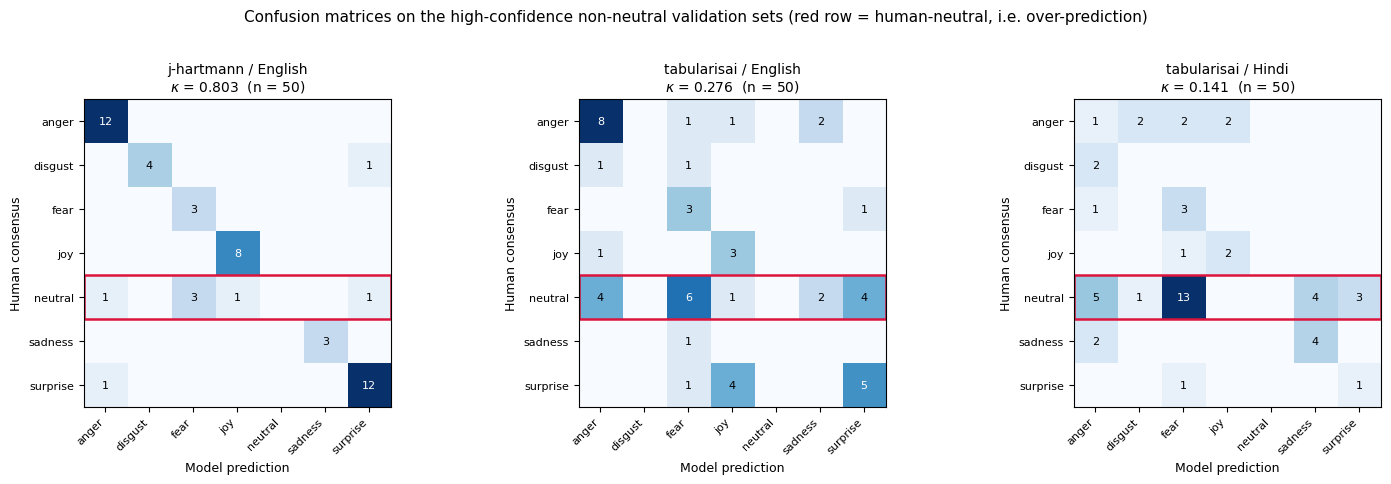

Saved -> fig_confusion_matrices.pdf  (vector PDF)

j-hartmann / English: n=50, over-predicted (human-neutral)=6 (12%)
  annotated-label frequency: {'anger': 12, 'disgust': 5, 'fear': 3, 'joy': 8, 'neutral': 6, 'sadness': 3, 'surprise': 13}
tabularisai / English: n=50, over-predicted (human-neutral)=17 (34%)
  annotated-label frequency: {'anger': 12, 'disgust': 2, 'fear': 4, 'joy': 4, 'neutral': 17, 'sadness': 1, 'surprise': 10}
tabularisai / Hindi: n=50, over-predicted (human-neutral)=26 (52%)
  annotated-label frequency: {'anger': 7, 'disgust': 2, 'fear': 4, 'joy': 3, 'neutral': 26, 'sadness': 6, 'surprise': 2}


In [19]:
# ── 5.5 Per-configuration confusion matrices (human vs model) ─────────────────
# Reviewer request (R3): replace the predicted-distribution bars with confusion
# matrices so the reader can see (a) how often each label was ANNOTATED (row
# totals) and (b) exactly WHERE the model errs. Rows = human consensus (truth),
# columns = model prediction, over the 7 parity labels. Because every validated
# set is the model's own top-50 NON-neutral picks, the model-neutral column is
# structurally empty; the mass in the human-"neutral" ROW is the over-prediction.
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def _norm(s):
    s = re.sub(r"\s+", " ", str(s)).strip()
    return s.strip(" \t\r\n“”‘’\"'")

# Rebuild the three (human, model) label pairs from CSVs (same joins as 5.4).
# 1) j-hartmann / English
eng = pd.read_csv("english_validation.csv")
pairs_jh_en = (eng["manual_label"].str.strip().str.lower(),
               eng["pretrained_label"].str.strip().str.lower())

# 2) tabularisai / English  (annotated joined to preds on normalized text)
etab = pd.read_csv("english_tab_pred.csv")
etab["_key"] = etab["text"].map(_norm)
etab["parity_pred"] = etab["parity_pred"].str.strip().str.lower()
eta = pd.read_csv("english_tab_validation_annotated.csv")
eta["_key"] = eta["text"].map(_norm)
eta["human_label"] = eta["human_label"].str.strip().str.lower()
et = eta.merge(etab[["_key", "parity_pred"]], on="_key", how="inner")
pairs_tab_en = (et["human_label"], et["parity_pred"])

# 3) tabularisai / Hindi  (annotated joined to preds on turn_id)
gp = pd.read_csv("gaban_pred.csv"); gp["turn_id"] = gp["turn_id"].astype(int)
gp["parity_pred"] = gp["parity_pred"].str.strip().str.lower()
gh = pd.read_csv("gaban_validation_annotated.csv"); gh["turn_id"] = gh["turn_id"].astype(int)
gh["human_label"] = gh["human_label"].str.strip().str.lower()
hi = gh.merge(gp[["turn_id", "parity_pred"]], on="turn_id", how="inner")
pairs_hi = (hi["human_label"], hi["parity_pred"])

# Pull kappa from the saved summary so panel titles stay consistent with 5.4.
_summ = pd.read_csv("validation_summary.csv")
def _kappa(model, lang):
    r = _summ[(_summ.model == model) & (_summ.language == lang)]
    return float(r["kappa"].iloc[0]) if len(r) else float("nan")

PANELS = [
    ("j-hartmann / English", pairs_jh_en, _kappa("j-hartmann", "English")),
    ("tabularisai / English", pairs_tab_en, _kappa("tabularisai", "English")),
    ("tabularisai / Hindi",  pairs_hi,     _kappa("tabularisai", "Hindi")),
]

def _plot_cm(ax, human, model, title, kappa):
    human = list(human); model = list(model)
    cm = confusion_matrix(human, model, labels=EMOTION_LABELS)
    im = ax.imshow(cm, cmap="Blues", vmin=0)
    ax.set_xticks(range(len(EMOTION_LABELS))); ax.set_yticks(range(len(EMOTION_LABELS)))
    ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(EMOTION_LABELS, fontsize=8)
    ax.set_xlabel("Model prediction", fontsize=9)
    ax.set_ylabel("Human consensus", fontsize=9)
    ax.set_title(f"{title}\n$\\kappa$ = {kappa:.3f}  (n = {len(human)})", fontsize=10)
    thresh = cm.max() / 2 if cm.max() else 0.5
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            if cm[r, c]:
                ax.text(c, r, int(cm[r, c]), ha="center", va="center",
                        color="white" if cm[r, c] > thresh else "black", fontsize=8)
    # highlight the over-prediction row (human = neutral)
    nr = EMOTION_LABELS.index("neutral")
    ax.add_patch(plt.Rectangle((-0.5, nr - 0.5), len(EMOTION_LABELS), 1,
                               fill=False, edgecolor="crimson", lw=1.8))
    return im

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (title, (h, m), k) in zip(axes, PANELS):
    _plot_cm(ax, h, m, title, k)
fig.suptitle("Confusion matrices on the high-confidence non-neutral validation sets "
             "(red row = human-neutral, i.e. over-prediction)", fontsize=11, y=1.03)
fig.tight_layout()
CM_PDF = "fig_confusion_matrices.pdf"
fig.savefig(CM_PDF, bbox_inches="tight")
plt.show()

# Console: annotated-label frequency (row totals) + over-prediction count per panel
print(f"Saved -> {CM_PDF}  (vector PDF)\n")
for title, (h, m), k in PANELS:
    h = list(h)
    freq = pd.Series(h).value_counts().reindex(EMOTION_LABELS, fill_value=0)
    op = sum(1 for a, b in zip(h, list(m)) if a == "neutral" and b != "neutral")
    print(f"{title}: n={len(h)}, over-predicted (human-neutral)={op} ({op/len(h):.0%})")
    print("  annotated-label frequency:",
          {lbl: int(freq[lbl]) for lbl in EMOTION_LABELS if freq[lbl]})


### 5.6 Confidence characterization outside the top-50 probe

Addresses how fast confidence decays past the top-50 subset and whether over-prediction persists at lower confidence, plus a corpus-wide framing. (A) corpus-wide non-neutral confidence decay with the top-50 cutoff marked; (B) over-prediction vs confidence within the annotated (gold-labelled) range. Below that range there are no gold labels, so (B) is reported only where measurable and the boundary is stated explicitly.

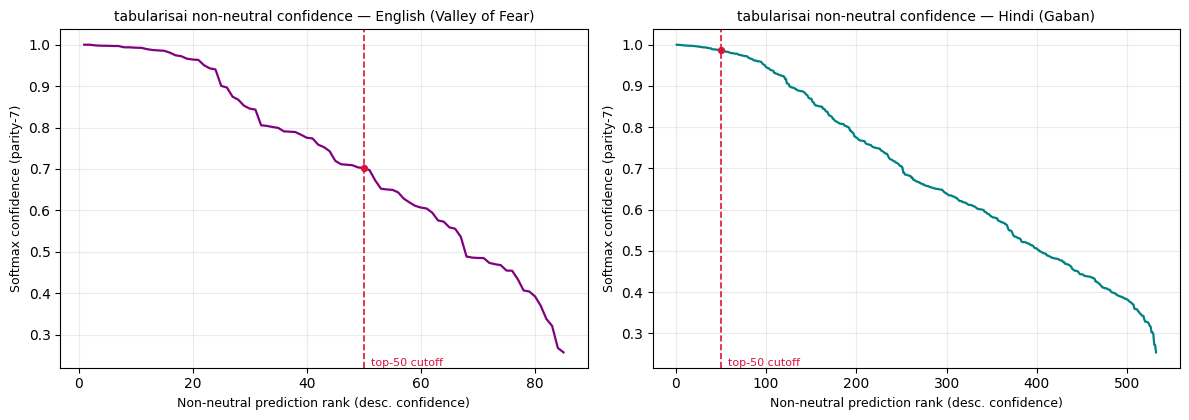

Saved -> fig_confidence_decay.pdf  (vector PDF)

English: corpus turns=172, neutral rate=50.6%, non-neutral=85
  confidence at rank 50 = 0.702; 59% of non-neutral predictions sit at/above that cutoff

Hindi: corpus turns=1044, neutral rate=49.0%, non-neutral=532
  confidence at rank 50 = 0.986; 9% of non-neutral predictions sit at/above that cutoff

tabularisai / English — over-prediction across the annotated confidence range (n=50, range 0.702–1.000):
  conf (0.701, 0.802]: n=17, over-prediction=35%
  conf (0.802, 0.973]: n=16, over-prediction=38%
  conf (0.973, 1.0]: n=17, over-prediction=29%

tabularisai / Hindi — over-prediction across the annotated confidence range (n=50, range 0.986–1.000):
  conf (0.985, 0.993]: n=17, over-prediction=53%
  conf (0.993, 0.997]: n=16, over-prediction=50%
  conf (0.997, 1.0]: n=17, over-prediction=53%

Note: over-prediction below the annotated range is not directly measured (no gold labels there); the decay curve (A) characterizes that region.


In [20]:
# ── 5.6 Confidence characterization: what lies outside the top-50 probe ───────
# Reviewer requests: R1 asks how fast confidence decays outside the top-50 subset
# and whether over-prediction persists at lower confidence; R4 asks for a corpus-
# wide framing alongside the targeted probe. Two honest views:
#   (A) corpus-wide decay curve of non-neutral confidence, with the top-50 cutoff
#       marked (shows how special / how steep the probed region is);
#   (B) over-prediction vs confidence WITHIN the annotated range, where gold
#       labels exist. Below that range there are no gold labels, so (B) is
#       reported only where it is measurable and the boundary is stated.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _decay(pred_csv, label):
    d = pd.read_csv(pred_csv)
    nn = d[d["parity_pred"] != "neutral"].sort_values("pred_prob", ascending=False).reset_index(drop=True)
    neutral_rate = float((d["parity_pred"] == "neutral").mean())
    cut = nn["pred_prob"].iloc[49] if len(nn) >= 50 else (nn["pred_prob"].min() if len(nn) else float("nan"))
    frac_above = float((nn["pred_prob"] >= cut).mean()) if len(nn) else float("nan")
    return d, nn, neutral_rate, cut, frac_above

en_all, en_nn, en_neu, en_cut, en_fa = _decay("english_tab_pred.csv", "English")
hi_all, hi_nn, hi_neu, hi_cut, hi_fa = _decay("gaban_pred.csv", "Hindi")

# ---- (A) decay curves ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, (nn, cut, name, color) in zip(
        axes, [(en_nn, en_cut, "English (Valley of Fear)", "purple"),
               (hi_nn, hi_cut, "Hindi (Gaban)", "teal")]):
    ax.plot(range(1, len(nn) + 1), nn["pred_prob"].values, color=color, lw=1.6)
    if len(nn) >= 50:
        ax.axvline(50, color="crimson", ls="--", lw=1.2)
        ax.text(50, ax.get_ylim()[0], "  top-50 cutoff", color="crimson",
                va="bottom", ha="left", fontsize=8)
        ax.scatter([50], [cut], color="crimson", zorder=5, s=18)
    ax.set_title(f"tabularisai non-neutral confidence — {name}", fontsize=10)
    ax.set_xlabel("Non-neutral prediction rank (desc. confidence)", fontsize=9)
    ax.set_ylabel("Softmax confidence (parity-7)", fontsize=9)
    ax.grid(alpha=0.25)
fig.tight_layout()
DECAY_PDF = "fig_confidence_decay.pdf"
fig.savefig(DECAY_PDF, bbox_inches="tight")
plt.show()

print(f"Saved -> {DECAY_PDF}  (vector PDF)")
for name, all_, nn, neu, cut, fa in [
        ("English", en_all, en_nn, en_neu, en_cut, en_fa),
        ("Hindi",   hi_all, hi_nn, hi_neu, hi_cut, hi_fa)]:
    print(f"\n{name}: corpus turns={len(all_)}, neutral rate={neu:.1%}, "
          f"non-neutral={len(nn)}")
    print(f"  confidence at rank 50 = {cut:.3f}; "
          f"{fa:.0%} of non-neutral predictions sit at/above that cutoff")

# ---- (B) over-prediction vs confidence within the annotated (gold) range ----
import re
def _norm(s):
    s = re.sub(r"\s+", " ", str(s)).strip()
    return s.strip(" \t\r\n“”‘’\"'")

# tabularisai/English annotated rows carry pred_prob via the pred file (join on text)
etab = pd.read_csv("english_tab_pred.csv"); etab["_key"] = etab["text"].map(_norm)
eta = pd.read_csv("english_tab_validation_annotated.csv"); eta["_key"] = eta["text"].map(_norm)
eta["human_label"] = eta["human_label"].str.strip().str.lower()
en_join = eta.merge(etab[["_key", "pred_prob"]], on="_key", how="inner")

# tabularisai/Hindi annotated rows carry pred_prob via gaban_pred (join on turn_id)
gp = pd.read_csv("gaban_pred.csv"); gp["turn_id"] = gp["turn_id"].astype(int)
gh = pd.read_csv("gaban_validation_annotated.csv"); gh["turn_id"] = gh["turn_id"].astype(int)
gh["human_label"] = gh["human_label"].str.strip().str.lower()
hi_join = gh.merge(gp[["turn_id", "pred_prob"]], on="turn_id", how="inner")

def _overpred_by_band(df, name, n_bands=3):
    df = df.sort_values("pred_prob", ascending=False).reset_index(drop=True)
    df["band"] = pd.qcut(df["pred_prob"], q=min(n_bands, df["pred_prob"].nunique()),
                         duplicates="drop")
    print(f"\n{name} — over-prediction across the annotated confidence range "
          f"(n={len(df)}, range {df['pred_prob'].min():.3f}–{df['pred_prob'].max():.3f}):")
    for band, sub in df.groupby("band", observed=True):
        op = (sub["human_label"] == "neutral").mean()
        print(f"  conf {band}: n={len(sub)}, over-prediction={op:.0%}")

_overpred_by_band(en_join, "tabularisai / English")
_overpred_by_band(hi_join, "tabularisai / Hindi")
print("\nNote: over-prediction below the annotated range is not directly measured "
      "(no gold labels there); the decay curve (A) characterizes that region.")


## 6. Emotion Distributions

### 6.1 English (tabularisai)

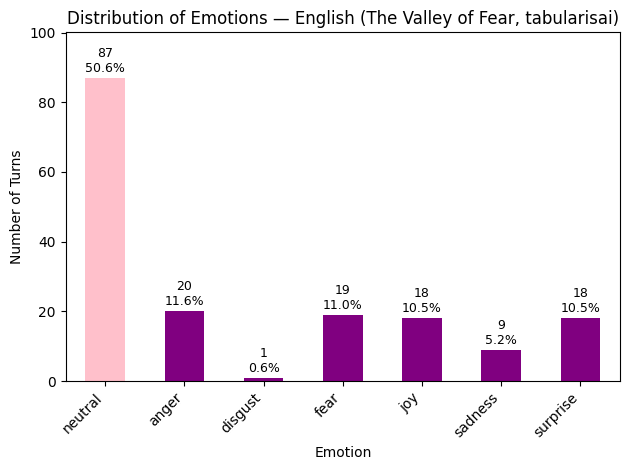

Saved -> fig_english_distribution.pdf  (vector PDF)
Total turns: 172
Counts / % by label (plot order):
  neutral     87  (50.6%)
  anger       20  (11.6%)
  disgust      1  (0.6%)
  fear        19  (11.0%)
  joy         18  (10.5%)
  sadness      9  (5.2%)
  surprise    18  (10.5%)
Overall neutral rate (English, tabularisai): 50.6%


In [21]:
# ── English emotion distribution: tabularisai over The Valley of Fear ────────
import matplotlib.pyplot as plt
import pandas as pd

ORDER = ["neutral", "anger", "disgust", "fear", "joy", "sadness", "surprise"]

pred = pd.read_csv("english_tab_pred.csv")
counts = pred["parity_pred"].value_counts().reindex(ORDER, fill_value=0)
total = int(counts.sum())
pcts = counts / total * 100.0

bar_colors = ["pink" if lbl == "neutral" else "purple" for lbl in ORDER]

ax = counts.plot(kind="bar", color=bar_colors)
plt.title("Distribution of Emotions — English (The Valley of Fear, tabularisai)")
plt.ylabel("Number of Turns")
plt.xlabel("Emotion")
plt.xticks(rotation=45, ha="right")

ymax = max(counts.max(), 1)
for i, lbl in enumerate(ORDER):
    ax.text(i, counts.iloc[i] + ymax * 0.01, f"{int(counts.iloc[i])}\n{pcts.iloc[i]:.1f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, ymax * 1.15)

plt.tight_layout()

PDF_PATH = "fig_english_distribution.pdf"
plt.savefig(PDF_PATH)
plt.show()

print(f"Saved -> {PDF_PATH}  (vector PDF)")
print(f"Total turns: {total}")
print("Counts / % by label (plot order):")
for lbl in ORDER:
    print(f"  {lbl:<9} {int(counts[lbl]):>4}  ({pcts[lbl]:.1f}%)")
print(f"Overall neutral rate (English, tabularisai): {pcts['neutral']:.1f}%")


### 6.2 Hindi (tabularisai)

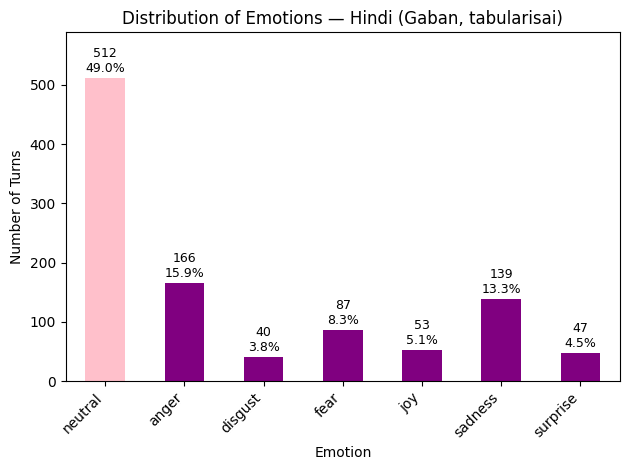


Saved -> fig_hindi_distribution.pdf  (vector PDF)
Total turns: 1044
Counts / % by label (plot order):
  neutral    512  (49.0%)
  anger      166  (15.9%)
  disgust     40  (3.8%)
  fear        87  (8.3%)
  joy         53  (5.1%)
  sadness    139  (13.3%)
  surprise    47  (4.5%)
Overall neutral rate (Hindi): 49.0%


In [22]:
# ── Hindi emotion distribution: tabularisai over Gaban ───────────────────────
import matplotlib.pyplot as plt
import pandas as pd

ORDER = ["neutral", "anger", "disgust", "fear", "joy", "sadness", "surprise"]

pred = pd.read_csv("gaban_pred.csv")
counts = pred["parity_pred"].value_counts().reindex(ORDER, fill_value=0)
total = int(counts.sum())
pcts = counts / total * 100.0

bar_colors = ["pink" if lbl == "neutral" else "purple" for lbl in ORDER]

ax = counts.plot(kind="bar", color=bar_colors)
plt.title("Distribution of Emotions — Hindi (Gaban, tabularisai)")
plt.ylabel("Number of Turns")
plt.xlabel("Emotion")
plt.xticks(rotation=45, ha="right")

ymax = max(counts.max(), 1)
for i, lbl in enumerate(ORDER):
    ax.text(i, counts.iloc[i] + ymax * 0.01, f"{int(counts.iloc[i])}\n{pcts.iloc[i]:.1f}%",
            ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, ymax * 1.15)

plt.tight_layout()

PDF_PATH = "fig_hindi_distribution.pdf"
plt.savefig(PDF_PATH)
plt.show()

print(f"\nSaved -> {PDF_PATH}  (vector PDF)")
print(f"Total turns: {total}")
print("Counts / % by label (plot order):")
for lbl in ORDER:
    print(f"  {lbl:<9} {int(counts[lbl]):>4}  ({pcts[lbl]:.1f}%)")
print(f"Overall neutral rate (Hindi): {pcts['neutral']:.1f}%")

## 7. Export

In [23]:
# --- Colab only: copy artifacts to Google Drive (skipped automatically off Colab) ---
ARTIFACTS = ['valley_of_fear.txt', 'valley_of_fear_processed.csv', 'valley_of_fear_processed.pkl',
             'english_tab_pred.csv', 'gaban_pred.csv', 'validation_summary.csv',
             'fig_english_distribution.pdf', 'fig_hindi_distribution.pdf',
             'fig_confusion_matrices.pdf', 'fig_confidence_decay.pdf']
try:
    from google.colab import drive
    import shutil
    drive.mount('/content/drive')
    save_dir = '/content/drive/MyDrive/valley_of_fear_analysis/'
    os.makedirs(save_dir, exist_ok=True)
    for f in ARTIFACTS:
        if os.path.exists(f):
            shutil.copy(f, save_dir)
    print("Copied artifacts to Google Drive.")
except (ModuleNotFoundError, ImportError):
    print("Not running on Colab - artifacts saved to the working directory:")
    for f in ARTIFACTS:
        print(f"  {'[ok]' if os.path.exists(f) else '[--]'} {f}")

Mounted at /content/drive
Copied artifacts to Google Drive.
